In [1]:
import numpy as np, pandas as pd, time, matplotlib.pyplot as plt
from gao_spiral import gao_spiral_v2, GAOParams, centroid, to_polar, gao_spiral_v2_1, gao_spiral_v3, gao_spiral_v3_1, gao_spiral_v4_fib_weave, gao_spiral_v5_dynamic_weave, gao_spiral_v6_adaptive_weave, gao_spiral_v6_adaptive_weave_2, gao_spiral_v7_hierarchical


In [2]:
def run_v2(label, n=200, seed=1, bins=None, w_theta=1.0, w_r=1.0):
    """Run GAO Spiral v2 and compute coherence scores."""
    np.random.seed(seed)
    pts = np.random.rand(n, 2).tolist()
    params = GAOParams(bins=bins, w_theta=w_theta, w_r=w_r)

    t0 = time.time()
    tour = gao_spiral_v2(pts, params)
    t1 = time.time()

    C = centroid(pts)
    r, theta = to_polar(pts, C)
    scores = gao_coherence_scores(pts, tour, r, theta, verbose=False)
    scores.update({"label": label, "build_time_ms": 1000 * (t1 - t0)})
    return scores

In [3]:
def run_v2_1(label, n=200, seed=1, bins=None, w_theta=1.0, w_r=1.0):
    """Run GAO Spiral v2 and compute coherence scores."""
    np.random.seed(seed)
    pts = np.random.rand(n, 2).tolist()
    params = GAOParams(bins=bins, w_theta=w_theta, w_r=w_r)

    t0 = time.time()
    tour = gao_spiral_v2_1(pts, params)
    t1 = time.time()

    C = centroid(pts)
    r, theta = to_polar(pts, C)
    scores = gao_coherence_scores(pts, tour, r, theta, verbose=False)
    scores.update({"label": label, "build_time_ms": 1000 * (t1 - t0)})
    return scores

In [4]:
def gao_coherence_scores(points, tour, r, theta, verbose=True):
    """
    Compute quantitative coherence metrics for GAO Spiral geometry.
    Returns a dict of normalized scores (0–1 range, higher = better).
    """

    n = len(points)
    r = np.array(r)
    theta = np.unwrap(theta)
    r_t = r[tour]
    theta_t = theta[tour]
    dr = np.diff(r_t)
    dtheta = np.diff(theta_t)
    B = int(2*np.sqrt(n))
    hist, _ = np.histogram(theta, bins=B)

    # --- Dualitas: coupling of radius & angle (correlation stability) ---
    corr = np.corrcoef(r_t[:-1], np.degrees(theta_t[:-1]) % 360)[0,1]
    dualitas_score = 1 - abs(corr)  # near-zero correlation → balanced polarity

    # --- Adaptatio: smoothness of radial flow ---
    mean_dr = np.mean(np.abs(dr))
    std_dr = np.std(np.abs(dr))
    adaptatio_score = 1 / (1 + std_dr / (mean_dr + 1e-9))  # lower variability → higher score

    # --- Textura: uniform bin occupancy ---
    cv_bins = np.std(hist) / (np.mean(hist) + 1e-9)
    textura_score = 1 / (1 + cv_bins)  # coefficient of variation

    # --- Ecologia: angular rhythm stability ---
    golden = 137.50776
    mean_dtheta = np.degrees(np.mean(np.abs(dtheta))) % 360
    std_dtheta = np.std(np.degrees(np.abs(dtheta)))
    ecologia_score = 1 / (1 + abs(mean_dtheta - golden)/golden + std_dtheta/180)

    # Aggregate: simple harmonic mean for overall coherence
    scores = {
        "Dualitas": dualitas_score,
        "Adaptatio": adaptatio_score,
        "Textura": textura_score,
        "Ecologia": ecologia_score
    }
    overall = np.mean(list(scores.values()))
    scores["Overall"] = overall

    if verbose:
        print("=== GAO Coherence Scores ===")
        for k,v in scores.items():
            print(f"{k:10s}: {v:6.3f}")
        print("============================")

    return scores

In [5]:
scenarios_v2 = [
    ("Base v2", {}),
    ("Wide bins v2", {"bins": int(3*np.sqrt(200))}),
    ("High w_r v2", {"w_r": 1.5}),
    ("High w_theta v2", {"w_theta": 1.5}),
    ("Balanced tuned v2", {"w_theta": 1.2, "w_r": 1.3}),
]
results_v2 = [run_v2(name, **kw) for name, kw in scenarios_v2]
results_v2_1 = [run_v2_1(name, **kw) for name, kw in scenarios_v2]
df_v2 = pd.DataFrame(results_v2)
cols = ["label","Dualitas","Adaptatio","Textura","Ecologia","Overall","build_time_ms"]
display(df_v2[cols].sort_values("Overall", ascending=False))

df_v2_1 = pd.DataFrame(results_v2_1)
cols = ["label","Dualitas","Adaptatio","Textura","Ecologia","Overall","build_time_ms"]
display(df_v2_1[cols].sort_values("Overall", ascending=False))


,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
2,High w_r v2,0.942230,0.499215,0.594355,0.203260,0.559765,12.468338
3,High w_theta v2,0.942230,0.503991,0.594355,0.187015,0.556898,12.573957
0,Base v2,0.936390,0.478358,0.594355,0.195181,0.551071,17.243862
1,Wide bins v2,0.945590,0.458904,0.594355,0.196498,0.548837,12.941837
4,Balanced tuned v2,0.954444,0.431047,0.594355,0.198589,0.544609,12.396097


,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
1,Wide bins v2,0.945590,0.537658,0.594355,0.195557,0.568290,14.707088
3,High w_theta v2,0.939186,0.449897,0.594355,0.194211,0.544412,15.977859
0,Base v2,0.942230,0.444787,0.594355,0.193505,0.543719,15.532255
2,High w_r v2,0.954444,0.417254,0.594355,0.206882,0.543234,15.370846
4,Balanced tuned v2,0.942230,0.403958,0.594355,0.193156,0.533425,15.148163


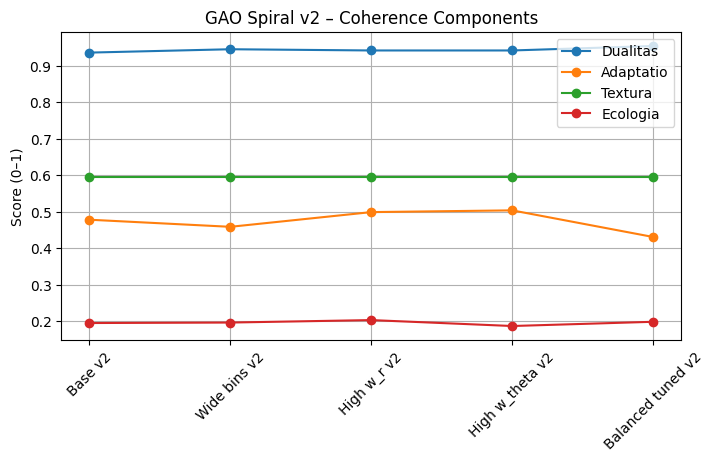

Best scenario: High w_r v2
  Adaptatio=0.499, Ecologia=0.203, Textura=0.594

Interpretation:
• Expect Adaptatio > 0.7 if radial continuity improved.
• Ecologia should stay >= 0.25 (stable rotation rhythm).
• If both improve together, 2D Textura grid works as intended.


In [6]:
plt.figure(figsize=(8,4))
for col in ["Dualitas","Adaptatio","Textura","Ecologia"]:
    plt.plot(df_v2["label"], df_v2[col], marker='o', label=col)
plt.xticks(rotation=45)
plt.ylabel("Score (0–1)")
plt.title("GAO Spiral v2 – Coherence Components")
plt.legend()
plt.grid(True)
plt.show()

best = df_v2.loc[df_v2["Overall"].idxmax()]
print(f"Best scenario: {best.label}")
print(f"  Adaptatio={best.Adaptatio:.3f}, Ecologia={best.Ecologia:.3f}, Textura={best.Textura:.3f}")
print("\nInterpretation:")
print("• Expect Adaptatio > 0.7 if radial continuity improved.")
print("• Ecologia should stay >= 0.25 (stable rotation rhythm).")
print("• If both improve together, 2D Textura grid works as intended.")


In [7]:
def run_v3(label, n=200, seed=1, bins=None, w_theta=1.0, w_r=1.0):
    np.random.seed(seed)
    pts = np.random.rand(n, 2).tolist()
    params = GAOParams(bins=bins, w_theta=w_theta, w_r=w_r)
    t0 = time.time()
    tour = gao_spiral_v3(pts, params)
    t1 = time.time()
    C = centroid(pts); r, theta = to_polar(pts, C)
    scores = gao_coherence_scores(pts, tour, r, theta, verbose=False)
    scores.update({"label": label, "build_time_ms": 1000 * (t1 - t0)})
    return scores


In [8]:
scenarios_v3 = [
    ("Base v3", {}),
    ("Wide bins v3", {"bins": int(3*np.sqrt(200))}),
    ("High w_r v3", {"w_r": 1.5}),
    ("High w_theta v3", {"w_theta": 1.5}),
    ("Balanced tuned v3", {"w_theta": 1.2, "w_r": 1.3}),
]

results_v3 = [run_v3(name, **kw) for name, kw in scenarios_v3]
df_v3 = pd.DataFrame(results_v3)
cols = ["label", "Dualitas", "Adaptatio", "Textura", "Ecologia", "Overall", "build_time_ms"]
display(df_v3[cols].sort_values("Overall", ascending=False))

,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
3,High w_theta v3,0.939381,0.556503,0.594355,0.210405,0.575161,16.187191
2,High w_r v3,0.936575,0.519842,0.594355,0.208871,0.564911,16.062021
1,Wide bins v3,0.942230,0.497706,0.594355,0.207956,0.560562,15.951872
4,Balanced tuned v3,0.942230,0.510351,0.594355,0.187970,0.558727,16.414881
0,Base v3,0.942230,0.444543,0.594355,0.200215,0.545336,19.808054


In [9]:
def run_v3_1(label, n=200, seed=1, bins=None, w_theta=1.0, w_r=1.0):
    np.random.seed(seed)
    pts = np.random.rand(n, 2).tolist()
    params = GAOParams(bins=bins, w_theta=w_theta, w_r=w_r)
    t0 = time.time()
    tour = gao_spiral_v3_1(pts, params)
    t1 = time.time()
    C = centroid(pts); r, theta = to_polar(pts, C)
    scores = gao_coherence_scores(pts, tour, r, theta, verbose=False)
    scores.update({"label": label, "build_time_ms": 1000 * (t1 - t0)})
    return scores


In [10]:
scenarios_v3_1 = [
    ("Base v3", {}),
    ("Wide bins v3", {"bins": int(3*np.sqrt(200))}),
    ("High w_r v3", {"w_r": 1.5}),
    ("High w_theta v3", {"w_theta": 1.5}),
    ("Balanced tuned v3", {"w_theta": 1.2, "w_r": 1.3}),
]

results_v3_1 = [run_v3_1(name, **kw) for name, kw in scenarios_v3_1]
df_v3_1 = pd.DataFrame(results_v3_1)
cols = ["label", "Dualitas", "Adaptatio", "Textura", "Ecologia", "Overall", "build_time_ms"]
display(df_v3_1[cols].sort_values("Overall", ascending=False))

,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
4,Balanced tuned v3,0.940485,0.539174,0.594355,0.193243,0.566814,18.028975
1,Wide bins v3,0.942230,0.522335,0.594355,0.206996,0.566479,20.508051
3,High w_theta v3,0.947931,0.521535,0.594355,0.200654,0.566119,17.810106
0,Base v3,0.929712,0.477801,0.594355,0.189960,0.547957,30.513048
2,High w_r v3,0.942230,0.437336,0.594355,0.208381,0.545576,18.017054


In [11]:
def run_v4(label, n=200, seed=1, bins=None, w_theta=1.0, w_r=1.0):
    np.random.seed(seed)
    pts = np.random.rand(n,2).tolist()
    params = GAOParams(bins=bins, w_theta=w_theta, w_r=w_r)
    import time
    t0 = time.time()
    tour = gao_spiral_v4_fib_weave(pts, params)
    t1 = time.time()
    C = centroid(pts); r, th = to_polar(pts, C)
    # uses your existing metric function:
    s = gao_coherence_scores(pts, tour, r, th, verbose=False)
    s.update({"label": label, "build_time_ms": 1000*(t1-t0)})
    return s

In [12]:
# --- GAO Spiral v4: Scenario definitions ---
scenarios_v4 = [
    ("Base v4", {}),
    ("Wide bins v4", {"bins": int(3 * np.sqrt(200))}),
    ("High w_r v4", {"w_r": 1.5}),
    ("High w_theta v4", {"w_theta": 1.5}),
    ("Balanced tuned v4", {"w_theta": 1.2, "w_r": 1.3}),
]

# --- Run all scenarios ---
results_v4 = [run_v4(name, **kw) for name, kw in scenarios_v4]

# --- Display results ---
df_v4 = pd.DataFrame(results_v4)
cols = ["label", "Dualitas", "Adaptatio", "Textura", "Ecologia", "Overall", "build_time_ms"]
display(df_v4[cols].sort_values("Overall", ascending=False))


,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
1,Wide bins v4,0.928883,0.474353,0.594355,0.201235,0.549707,20.869732
0,Base v4,0.928883,0.461476,0.594355,0.196950,0.545416,33.487797
2,High w_r v4,0.927865,0.440661,0.594355,0.202293,0.541294,18.938065
3,High w_theta v4,0.942230,0.427441,0.594355,0.190635,0.538665,19.263029
4,Balanced tuned v4,0.927267,0.433889,0.594355,0.195893,0.537851,18.587112


In [13]:
def run_v5(label, n=200, seed=1, bins=None, w_theta=1.0, w_r=1.0):
    np.random.seed(seed)
    pts = np.random.rand(n,2).tolist()
    params = GAOParams(bins=bins, w_theta=w_theta, w_r=w_r)
    import time
    t0 = time.time()
    tour = gao_spiral_v5_dynamic_weave(pts, params)
    t1 = time.time()
    C = centroid(pts); r, th = to_polar(pts, C)
    s = gao_coherence_scores(pts, tour, r, th, verbose=False)
    s.update({"label": label, "build_time_ms": 1000*(t1-t0)})
    return s

scenarios_v5 = [
    ("Base v5", {}),
    ("Wide bins v5", {"bins": int(3*np.sqrt(200))}),
    ("High w_r v5", {"w_r": 1.5}),
    ("High w_theta v5", {"w_theta": 1.5}),
    ("Balanced tuned v5", {"w_theta": 1.2, "w_r": 1.3}),
]

results_v5 = [run_v5(name, **kw) for name, kw in scenarios_v5]
df_v5 = pd.DataFrame(results_v5)
cols = ["label", "Dualitas", "Adaptatio", "Textura", "Ecologia", "Overall", "build_time_ms"]
display(df_v5[cols].sort_values("Overall", ascending=False))


,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
0,Base v5,0.944896,0.390045,0.594355,0.215686,0.536246,24.242878
2,High w_r v5,0.945440,0.409621,0.594355,0.192016,0.535358,20.428181
3,High w_theta v5,0.945440,0.390857,0.594355,0.194562,0.531303,20.389080
4,Balanced tuned v5,0.950060,0.382484,0.594355,0.195068,0.530492,20.741940
1,Wide bins v5,0.942230,0.384628,0.594355,0.191126,0.528085,19.838095


In [14]:
def run_v6(label, n=200, seed=1, bins=None, w_theta=1.0, w_r=1.0):
    np.random.seed(seed)
    pts = np.random.rand(n,2).tolist()
    params = GAOParams(bins=bins, w_theta=w_theta, w_r=w_r)
    import time
    t0 = time.time()
    tour = gao_spiral_v6_adaptive_weave(pts, params)
    t1 = time.time()
    C = centroid(pts); r, th = to_polar(pts, C)
    s = gao_coherence_scores(pts, tour, r, th, verbose=False)
    s.update({"label": label, "build_time_ms": 1000*(t1-t0)})
    return s

scenarios_v6 = [
    ("Base v6", {}),
    ("Wide bins v6", {"bins": int(3*np.sqrt(200))}),
    ("High w_r v6", {"w_r": 1.5}),
    ("High w_theta v6", {"w_theta": 1.5}),
    ("Balanced tuned v6", {"w_theta": 1.2, "w_r": 1.3}),
]

results_v6 = [run_v6(name, **kw) for name, kw in scenarios_v6]
df_v6 = pd.DataFrame(results_v6)
cols = ["label", "Dualitas", "Adaptatio", "Textura", "Ecologia", "Overall", "build_time_ms"]
display(df_v6[cols].sort_values("Overall", ascending=False))


,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
0,Base v6,0.949046,0.412420,0.594355,0.201402,0.539306,35.258055
3,High w_theta v6,0.950060,0.413368,0.594355,0.198447,0.539058,20.791769
1,Wide bins v6,0.948138,0.414775,0.594355,0.194707,0.537994,21.696091
4,Balanced tuned v6,0.933439,0.410051,0.594355,0.191033,0.532220,20.456791
2,High w_r v6,0.944896,0.383863,0.594355,0.191898,0.528753,20.704985


In [15]:
def run_v6(label, n=200, seed=1, bins=None, w_theta=1.0, w_r=1.0,
           weave_mode="none", bias_rate=0.0, k_elast=0.25, k_curvgrid=0.15):
    """
    Execute GAO Spiral v6 with the given configuration and return coherence metrics.

    Args:
        label (str): descriptive label for the scenario
        n (int): number of points
        seed (int): RNG seed
        bins (int): optional angular bin count
        w_theta, w_r (float): weighting parameters
        weave_mode (str): one of "none", "bias", "elastic", "curvature"
        bias_rate (float): rotation rate for bias weave
        k_elast (float): elasticity factor for elastic weave
        k_curvgrid (float): curvature feedback strength for curvature weave
    """
    import numpy as np, time
    np.random.seed(seed)
    pts = np.random.rand(n, 2).tolist()

    params = GAOParams(
        bins=bins,
        w_theta=w_theta,
        w_r=w_r,
        weave_mode=weave_mode,
        bias_rate=bias_rate,
        k_elast=k_elast,
        k_curvgrid=k_curvgrid,
    )

    t0 = time.time()
    tour = gao_spiral_v6_adaptive_weave(pts, params)
    t1 = time.time()

    C = centroid(pts)
    r, th = to_polar(pts, C)
    s = gao_coherence_scores(pts, tour, r, th, verbose=False)
    s.update({"label": label, "build_time_ms": 1000 * (t1 - t0)})
    return s


# --- Scenario suite for GAO Spiral v6 (adaptive + weave modes) ---

scenarios_v6 = [
    ("Base v6", {}),
    ("Wide bins v6", {"bins": int(3 * np.sqrt(200))}),
    ("High w_r v6", {"w_r": 1.5}),
    ("High w_theta v6", {"w_theta": 1.5}),
    ("Balanced tuned v6", {"w_theta": 1.2, "w_r": 1.3}),
    # New weaving modes
    ("Bias-weave v6", {"weave_mode": "bias", "bias_rate": (2 * np.pi) / (200 * 6)}),
    ("Elastic-weave v6", {"weave_mode": "elastic", "k_elast": 0.25}),
    ("Curvature-weave v6", {"weave_mode": "curvature", "k_curvgrid": 0.15}),
    ("Hybrid v6", {
        "weave_mode": "bias",
        "bias_rate": (2 * np.pi) / (200 * 6),
        "k_elast": 0.20,
        "k_curvgrid": 0.10,
    }),
]

# --- Execute all scenarios and show results ---

results_v6 = [run_v6(name, **kw) for name, kw in scenarios_v6]
df_v6 = pd.DataFrame(results_v6)

cols = ["label", "Dualitas", "Adaptatio", "Textura", "Ecologia", "Overall", "build_time_ms"]
display(df_v6[cols].sort_values("Overall", ascending=False))


,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
0,Base v6,0.949046,0.412420,0.594355,0.201402,0.539306,30.167580
5,Bias-weave v6,0.949046,0.412420,0.594355,0.201402,0.539306,20.906925
6,Elastic-weave v6,0.949046,0.412420,0.594355,0.201402,0.539306,20.667076
7,Curvature-weave v6,0.949046,0.412420,0.594355,0.201402,0.539306,20.502090
8,Hybrid v6,0.949046,0.412420,0.594355,0.201402,0.539306,20.239115
3,High w_theta v6,0.950060,0.413368,0.594355,0.198447,0.539058,21.678209
1,Wide bins v6,0.948138,0.414775,0.594355,0.194707,0.537994,20.849943
4,Balanced tuned v6,0.933439,0.410051,0.594355,0.191033,0.532220,22.906303
2,High w_r v6,0.944896,0.383863,0.594355,0.191898,0.528753,21.064997


In [17]:
def run_v7(label, n=400, seed=1, bins=None, w_theta=1.0, w_r=1.0,
           weave_mode="none", k_clusters=5, **kwargs):
    import numpy as np, time
    np.random.seed(seed)
    pts = np.random.rand(n, 2).tolist()

    params = GAOParams(bins=bins, w_theta=w_theta, w_r=w_r,
                       weave_mode=weave_mode, **kwargs)

    t0 = time.time()
    tour = gao_spiral_v7_hierarchical(pts, params, k_clusters=k_clusters)
    t1 = time.time()

    C = centroid(pts); r, th = to_polar(pts, C)
    s = gao_coherence_scores(pts, tour, r, th, verbose=False)
    s.update({"label": label, "build_time_ms": 1000*(t1-t0)})
    return s



scenarios_v7 = [
    ("Base v7", {}),
    ("Bias-weave v7", {"weave_mode": "bias", "bias_rate": (2*np.pi)/(400*6)}),
    ("Elastic-weave v7", {"weave_mode": "elastic", "k_elast": 0.25}),
    ("Curvature-weave v7", {"weave_mode": "curvature", "k_curvgrid": 0.15}),
    ("Hybrid v7", {"weave_mode": "bias", "bias_rate": (2*np.pi)/(400*6),
                   "k_elast": 0.20, "k_curvgrid": 0.10}),
]

results_v7 = [run_v7(name, **kw) for name, kw in scenarios_v7]
df_v7 = pd.DataFrame(results_v7)
cols = ["label","Dualitas","Adaptatio","Textura","Ecologia","Overall","build_time_ms"]
display(df_v7[cols].sort_values("Overall", ascending=False))


,label,Dualitas,Adaptatio,Textura,Ecologia,Overall,build_time_ms
0,Base v7,0.996532,0.589353,0.537064,0.199316,0.580566,142.922401
1,Bias-weave v7,0.996532,0.589353,0.537064,0.199316,0.580566,175.996780
2,Elastic-weave v7,0.996532,0.589353,0.537064,0.199316,0.580566,381.714821
3,Curvature-weave v7,0.996532,0.589353,0.537064,0.199316,0.580566,93.132973
4,Hybrid v7,0.996532,0.589353,0.537064,0.199316,0.580566,89.424133
